In [125]:
import pandas as pd

In [126]:
orders = pd.read_csv('input-lab2/orders.csv')

In [127]:
customers = pd.read_json('input-lab2/customers.json')

In [128]:
products = pd.read_csv('input-lab2/products.csv')

In [129]:
print("--- Orders ---")
print(orders.head())
print("\n--- Customers ---")
print(customers.head())
print("\n--- Products ---")
print(products.head())
print("\nShapes:", orders.shape, customers.shape, products.shape)

--- Orders ---
  Order_ID Customer_ID Product_ID  Quantity  Order_Date
0     O101        C101       P101         2  2026-08-01
1     O102        C102       P102         1  2026-08-01
2     O103        C103       P103         3  2026-08-02
3     O104        C104       P101         1  2026-08-02
4     O105        C101       P102         2  2026-08-03

--- Customers ---
  Customer_ID Customer_Name       City
0        C101         Rahul      Delhi
1        C102         Priya     Mumbai
2        C103          Amit      Delhi
3        C104         Sonal  Bangalore
4        C105          Neha    Chennai

--- Products ---
  Product_ID Product_Name     Category  Price
0       P101       Laptop  Electronics  55000
1       P102        Mouse  Accessories    800
2       P103     Keyboard  Accessories   1500

Shapes: (10, 5) (5, 3) (3, 4)


In [130]:
print("--- Orders dtypes ---")
print(orders.dtypes)
print("\n--- Customers dtypes ---")
print(customers.dtypes)
print("\n--- Products dtypes ---")
print(products.dtypes)

--- Orders dtypes ---
Order_ID         str
Customer_ID      str
Product_ID       str
Quantity       int64
Order_Date       str
dtype: object

--- Customers dtypes ---
Customer_ID      str
Customer_Name    str
City             str
dtype: object

--- Products dtypes ---
Product_ID        str
Product_Name      str
Category          str
Price           int64
dtype: object


In [131]:
print("Orders Nulls:\n", orders.isnull().sum())
print("\nCustomers Nulls:\n", customers.isnull().sum())
print("\nProducts Nulls:\n", products.isnull().sum())

Orders Nulls:
 Order_ID       0
Customer_ID    0
Product_ID     0
Quantity       0
Order_Date     0
dtype: int64

Customers Nulls:
 Customer_ID      0
Customer_Name    0
City             0
dtype: int64

Products Nulls:
 Product_ID      0
Product_Name    0
Category        0
Price           0
dtype: int64


In [132]:
print("Orders Duplicates:", orders.duplicated().sum())
print("Customers Duplicates:", customers.duplicated().sum())
print("Products Duplicates:", products.duplicated().sum())

Orders Duplicates: 0
Customers Duplicates: 0
Products Duplicates: 0


In [133]:
orders = orders.drop_duplicates()
customers = customers.drop_duplicates()
products = products.drop_duplicates()

In [134]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

In [135]:
order_customer = pd.merge(orders, customers, on='Customer_ID', how='left')

In [136]:
final_df = pd.merge(order_customer, products, on='Product_ID', how='left')

In [137]:
final_df['Total_Amount'] = final_df['Quantity'] * final_df['Price']

In [138]:
final_df['City'] = final_df['City'].str.strip().str.title()
final_df['Category'] = final_df['Category'].str.strip().str.title()

In [139]:
final_df.info()
print("\nMissing values in final dataframe:\n", final_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       10 non-null     str           
 1   Customer_ID    10 non-null     str           
 2   Product_ID     10 non-null     str           
 3   Quantity       10 non-null     int64         
 4   Order_Date     10 non-null     datetime64[us]
 5   Customer_Name  10 non-null     str           
 6   City           10 non-null     str           
 7   Product_Name   10 non-null     str           
 8   Category       10 non-null     str           
 9   Price          10 non-null     int64         
 10  Total_Amount   10 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(7)
memory usage: 1.4 KB

Missing values in final dataframe:
 Order_ID         0
Customer_ID      0
Product_ID       0
Quantity         0
Order_Date       0
Customer_Name    0
City             0
Product_Nam

In [140]:
print('Total Revenue:', final_df['Total_Amount'].sum())

Total Revenue: 398100


In [141]:
city_revenue = final_df.groupby('City')['Total_Amount'].sum()
print(city_revenue)

City
Bangalore    165000
Chennai        3200
Delhi        227600
Mumbai         2300
Name: Total_Amount, dtype: int64


In [142]:
product_revenue = final_df.groupby('Product_Name')['Total_Amount'].sum()
print(product_revenue)

Product_Name
Keyboard      7500
Laptop      385000
Mouse         5600
Name: Total_Amount, dtype: int64


In [143]:
product_quantity = final_df.groupby('Product_Name')['Quantity'].sum()
print(product_quantity.sort_values(ascending=False))

Product_Name
Laptop      7
Mouse       7
Keyboard    5
Name: Quantity, dtype: int64


In [144]:
daily_revenue = final_df.groupby('Order_Date')['Total_Amount'].sum()
print(daily_revenue)

Order_Date
2026-08-01    110800
2026-08-02     59500
2026-08-03      3100
2026-08-04    113200
2026-08-05    111500
Name: Total_Amount, dtype: int64


In [145]:
final_df.to_csv('output-lab2/final_etl_dataset.csv', index=False)

In [146]:
summary = final_df.groupby('Category')['Total_Amount'].agg(['sum', 'mean', 'count'])
print(summary)

                sum          mean  count
Category                                
Accessories   13100   2183.333333      6
Electronics  385000  96250.000000      4


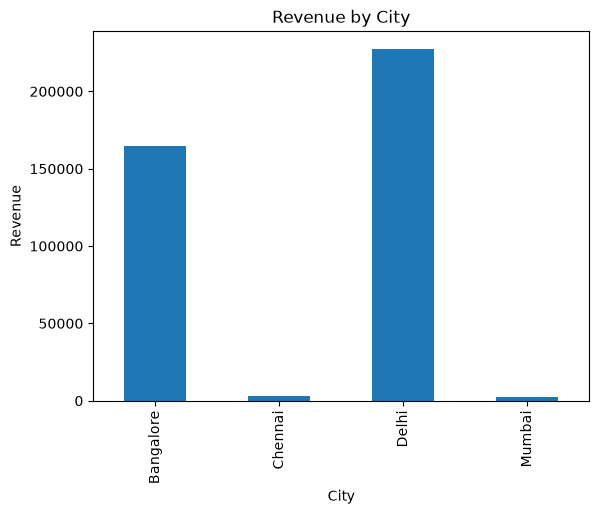

In [147]:
import matplotlib.pyplot as plt
city_revenue.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.show()

In [148]:
import dask.dataframe as dd

In [149]:
orders_dask = dd.read_csv('input-lab2/orders.csv')

In [150]:
print(orders_dask.head())

  Order_ID Customer_ID Product_ID  Quantity  Order_Date
0     O101        C101       P101         2  2026-08-01
1     O102        C102       P102         1  2026-08-01
2     O103        C103       P103         3  2026-08-02
3     O104        C104       P101         1  2026-08-02
4     O105        C101       P102         2  2026-08-03


In [151]:
products_dask = dd.read_csv('input-lab2/products.csv')

In [152]:
print(orders_dask.dtypes)

Order_ID       string
Customer_ID    string
Product_ID     string
Quantity        int64
Order_Date     string
dtype: object


In [153]:
merged_dask = orders_dask.merge(products_dask, on='Product_ID', how='left')

In [154]:
merged_dask['Total_Amount'] = merged_dask['Quantity'] * merged_dask['Price']

In [155]:
revenue_by_product = merged_dask.groupby('Product_Name')['Total_Amount'].sum()

In [156]:
result = revenue_by_product.compute()
print(result)

Product_Name
Keyboard      7500
Laptop      385000
Mouse         5600
Name: Total_Amount, dtype: int64


In [157]:
result.to_csv('output-lab2/dask_product_revenue.csv')